Simulation of light and eutrophication
Author: Marc López  
Course: Computational Marine Ecological Modelling  
Date: 2026

# 1. Introduction

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import solve_ivp

In [2]:
#Same Grid Ex2
depth = 100
Nz = 50

z = np.linspace(0, depth, Nz)
dz = z[1] - z[0]

In [3]:
g_p_max = 1.0
k_L = 20
k_N = 0.3

g_z_max = 1.0
k_P = 1.0

eps = 0.3
eps_f = 0.3

m_p = 0.07
m_z = 0.2

r = 0.1

N_deep = 10
kappa = 0.3
L0 = 1400


k_O = 5
y_P = 9
O_surface = 260

# mixing scenario switch
high_mixing = False

In [4]:
def mixing_depth(t, z_mix_min=10, z_mix_max=60):

    z_mix = 0.5 * (1 - np.sin(2*np.pi*t/365)) * (z_mix_max - z_mix_min) + z_mix_min

    return z_mix

In [ ]:
def diffusivity(z, t, k_surface=50, k_bottom=0.1, zeta=5):
    z_mix = mixing_depth(t)
    
    kappa = 0.5 * (1 - np.tanh((z - z_mix)/zeta)) * (k_surface - k_bottom) + k_bottom
    
    return kappa

In [6]:
def light_profile(P, z, L0, kw=0.04, kp=0.03):

    cumulative_P = np.cumsum(P) * dz
    
    light = L0 * np.exp(-(kw*z + kp*cumulative_P))
    
    return light

In [7]:
def light_profile_water_only(z, L0, kw=0.04):

    light = L0 * np.exp(-kw * z)

    return light

In [8]:
def surface_light(t, Lmax=1400):

    L = Lmax * (0.5 + 0.5*np.sin(2*np.pi*(t-80)/365))

    return L

In [9]:
# Variables with vertical dimension
N = np.linspace(10,1,Nz)
P = np.ones(Nz)*0.05
Z = np.ones(Nz)*0.02
D = np.ones(Nz)*0.02
O = np.zeros(Nz)
y0 = np.concatenate([N, P, Z, D, O])

In [ ]:
def npzd_water_column(t, y):

    N = y[0:Nz]
    P = y[Nz:2*Nz]
    Z = y[2*Nz:3*Nz]
    D = y[3*Nz:4*Nz]
    O = y[4*Nz:5*Nz]

    L_surface = surface_light(t)

    if use_phyto_shading:
        light = light_profile(P, z, L_surface)
    else:
        light = light_profile_water_only(z, L_surface)

    global high_mixing
    
    kappa_z = diffusivity(z, t)

    if high_mixing:
        kappa_z = np.ones(Nz) * 50

    dN = np.zeros(Nz)
    dP = np.zeros(Nz)
    dZ = np.zeros(Nz)
    dD = np.zeros(Nz)
    dO = np.zeros(Nz)


    for i in range(Nz):
        # growth rates
        g_p = g_p_max * min(light[i]/(light[i]+k_L), N[i]/(N[i]+k_N))
        grazing = g_z_max * Z[i] * P[i] / (P[i] + k_P)

        # oxygen limitation
        O_switch = O[i] / (O[i] + k_O)

        dN[i] = - g_p*P[i] + eps*grazing + r*D[i]*O_switch
        dP[i] = g_p*P[i] - grazing - m_p*P[i]
        dZ[i] = (1-eps-eps_f)*grazing - m_z*Z[i]
        dD[i] = m_p*P[i] + m_z*Z[i] + eps_f*grazing - r*D[i]*O_switch

        # oxygen dynamics
        production = y_P * g_p * P[i]
        consumption = y_P * r * D[i] * O_switch
        dO[i] = production - consumption

    # 2. Vertial difusion (only inside layers)
    for i in range(1, Nz-1):
        dN[i] += kappa_z[i] * (N[i+1] - 2*N[i] + N[i-1]) / dz**2
        dP[i] += kappa_z[i] * (P[i+1] - 2*P[i] + P[i-1]) / dz**2
        dZ[i] += kappa_z[i] * (Z[i+1] - 2*Z[i] + Z[i-1]) / dz**2
        dD[i] += kappa_z[i] * (D[i+1] - 2*D[i] + D[i-1]) / dz**2
        dO[i] += kappa_z[i] * (O[i+1] - 2*O[i] + O[i-1]) / dz**2

    # 3. Boundary conditions (z = Nz-1)
    dN[-1] += kappa_z[-1] * (N_deep - N[-1]) / dz**2 + kappa_z[-1] * (N[-2] - N[-1]) / dz**2
    dP[-1] += kappa_z[-1] * (P[-2] - P[-1]) / dz**2
    dZ[-1] += kappa_z[-1] * (Z[-2] - Z[-1]) / dz**2
    dD[-1] += kappa_z[-1] * (D[-2] - D[-1]) / dz**2
    dO[-1] += kappa_z[-1] * (O[-2] - O[-1]) / dz**2

    # 4. Boundary conditions (z = 0)
    v_gas = 20 
    
    # Gas exchange of oxygen + diffusion with the layer below
    dO[0] += v_gas * (O_surface - O[0]) / dz + kappa_z[0] * (O[1] - O[0]) / dz**2
    dN[0] += kappa_z[0] * (N[1] - N[0]) / dz**2
    dP[0] += kappa_z[0] * (P[1] - P[0]) / dz**2
    dZ[0] += kappa_z[0] * (Z[1] - Z[0]) / dz**2
    dD[0] += kappa_z[0] * (D[1] - D[0]) / dz**2

 
    return np.concatenate((dN, dP, dZ, dD, dO))

In [11]:
t_span = (0,365)
t_eval = np.linspace(0,365,365)

# Summer simulation sin phytoplankton shading

In [12]:
use_phyto_shading = False

sol_no_shading = solve_ivp(npzd_water_column, t_span, y0, t_eval=t_eval)

# Summer simulation con phytoplankton shading

In [13]:
use_phyto_shading = True

sol_shading = solve_ivp(npzd_water_column, t_span, y0, t_eval=t_eval)

# Results

In [14]:
N_no = sol_no_shading.y[0:Nz,-1]
P_no = sol_no_shading.y[Nz:2*Nz,-1]
Z_no = sol_no_shading.y[2*Nz:3*Nz,-1]
D_no = sol_no_shading.y[3*Nz:4*Nz,-1]
O_no = sol_no_shading.y[4*Nz:5*Nz,-1]

N_sh = sol_shading.y[0:Nz,-1]
P_sh = sol_shading.y[Nz:2*Nz,-1]
Z_sh = sol_shading.y[2*Nz:3*Nz,-1]
D_sh = sol_shading.y[3*Nz:4*Nz,-1]
O_sh = sol_shading.y[4*Nz:5*Nz,-1]

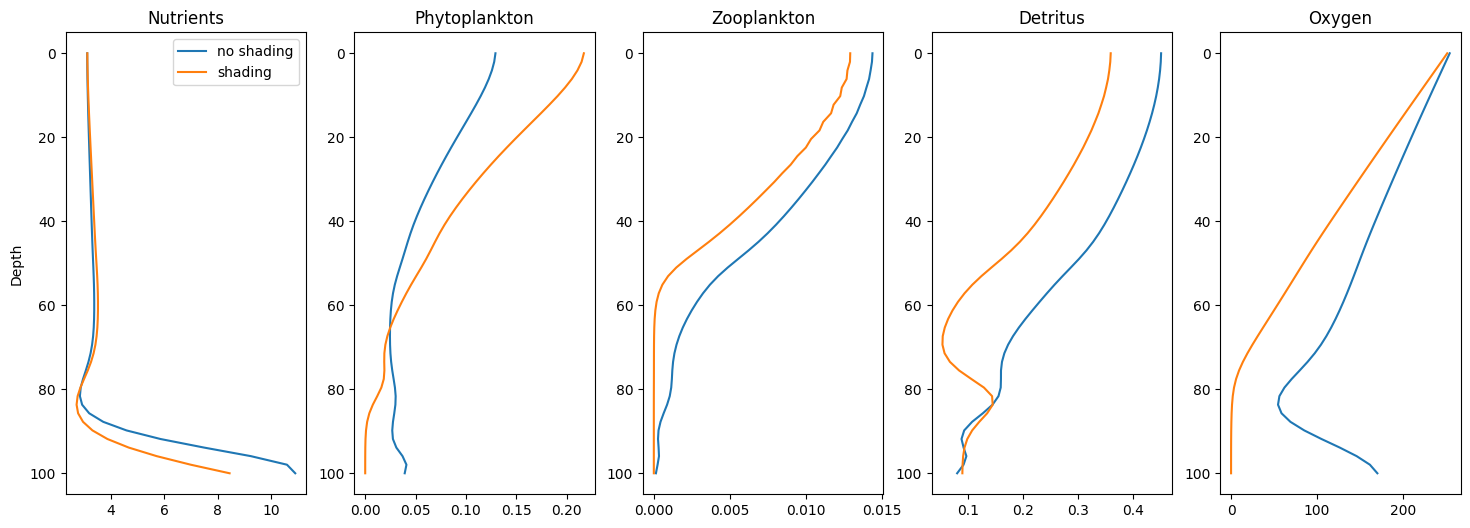

In [ ]:

fig, ax = plt.subplots(1,5, figsize=(18,6))

ax[0].plot(N_no,z,label="no shading")
ax[0].plot(N_sh,z,label="shading")

ax[1].plot(P_no,z)
ax[1].plot(P_sh,z)

ax[2].plot(Z_no,z)
ax[2].plot(Z_sh,z)

ax[3].plot(D_no,z)
ax[3].plot(D_sh,z)

ax[4].plot(O_no,z)
ax[4].plot(O_sh,z)


ax[0].set_title("Nutrients")
ax[1].set_title("Phytoplankton")
ax[2].set_title("Zooplankton")
ax[3].set_title("Detritus")
ax[4].set_title("Oxygen")

ax[0].set_ylabel("Depth")

ax[0].legend()

for a in ax:
    a.invert_yaxis()

plt.show()

# Scenario: High nutrient input

In [16]:
N_deep = 100

use_phyto_shading = True

sol_eutrophic = solve_ivp(npzd_water_column, t_span, y0, t_eval=t_eval)

In [17]:
P_eut = sol_eutrophic.y[Nz:2*Nz, -1]

In [18]:
Chl = P_eut / 8

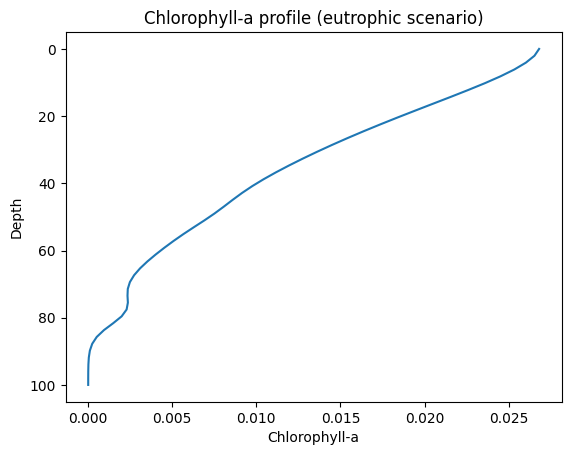

In [19]:
plt.plot(Chl, z)

plt.gca().invert_yaxis()

plt.xlabel("Chlorophyll-a")
plt.ylabel("Depth")

plt.title("Chlorophyll-a profile (eutrophic scenario)")

plt.show()

In [20]:
P_normal = sol_shading.y[Nz:2*Nz, -1]
Chl_normal = P_normal / 8

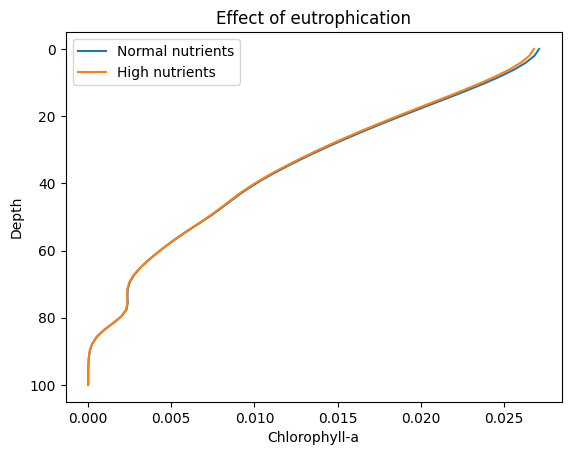

In [21]:
plt.plot(Chl_normal, z, label="Normal nutrients")
plt.plot(Chl, z, label="High nutrients")

plt.gca().invert_yaxis()

plt.xlabel("Chlorophyll-a")
plt.ylabel("Depth")

plt.title("Effect of eutrophication")

plt.legend()

plt.show()

In [22]:
print(z)

[  0.           2.04081633   4.08163265   6.12244898   8.16326531
  10.20408163  12.24489796  14.28571429  16.32653061  18.36734694
  20.40816327  22.44897959  24.48979592  26.53061224  28.57142857
  30.6122449   32.65306122  34.69387755  36.73469388  38.7755102
  40.81632653  42.85714286  44.89795918  46.93877551  48.97959184
  51.02040816  53.06122449  55.10204082  57.14285714  59.18367347
  61.2244898   63.26530612  65.30612245  67.34693878  69.3877551
  71.42857143  73.46938776  75.51020408  77.55102041  79.59183673
  81.63265306  83.67346939  85.71428571  87.75510204  89.79591837
  91.83673469  93.87755102  95.91836735  97.95918367 100.        ]


In [23]:
plt.figure(figsize=(5,7))

plt.plot(N_normal, z, linewidth=2, label="Normal nutrients")
plt.plot(N_eut, z, linewidth=2, label="High nutrients")

plt.gca().invert_yaxis()

plt.xlabel("Nutrient concentration")
plt.ylabel("Depth (m)")
plt.title("Vertical nutrient distribution")
plt.legend()
plt.grid()

plt.show()

NameError: name 'N_normal' is not defined

<Figure size 500x700 with 0 Axes>

In [ ]:
N_normal = sol_shading.y[0:Nz, -1]
N_eut = sol_eutrophic.y[0:Nz, -1]

plt.plot(N_normal, z, label="Normal nutrients")
plt.plot(N_eut, z, label="High nutrients")

plt.gca().invert_yaxis()
plt.xlabel("Nutrients")
plt.ylabel("Depth")
plt.legend()

# Seasonal simulation

In [ ]:
# Seasonal simulation

t_span = (0,365 * 5)
t_eval = np.linspace(0,365,365)

use_phyto_shading = True

sol_seasonal = solve_ivp(npzd_water_column, t_span, y0, t_eval=t_eval)

In [ ]:
N_surface = sol_seasonal.y[0, :]
P_surface = sol_seasonal.y[Nz, :]
Z_surface = sol_seasonal.y[2*Nz, :]
D_surface = sol_seasonal.y[3*Nz, :]

In [ ]:
plt.figure(figsize=(10,6))

plt.plot(sol_seasonal.t, N_surface, label="Nutrients")
plt.plot(sol_seasonal.t, P_surface, label="Phytoplankton")
plt.plot(sol_seasonal.t, Z_surface, label="Zooplankton")
plt.plot(sol_seasonal.t, D_surface, label="Detritus")

plt.xlabel("Day of year")
plt.ylabel("Surface concentration")
plt.title("Seasonal evolution of NPZD variables")

plt.legend()
plt.show()

In [ ]:
N_time = np.mean(sol_seasonal.y[0:Nz,:], axis=0)
P_time = np.mean(sol_seasonal.y[Nz:2*Nz,:], axis=0)
Z_time = np.mean(sol_seasonal.y[2*Nz:3*Nz,:], axis=0)
D_time = np.mean(sol_seasonal.y[3*Nz:4*Nz,:], axis=0)

In [ ]:
plt.figure(figsize=(10,6))

plt.plot(sol_seasonal.t, N_time, label="Nutrients")
plt.plot(sol_seasonal.t, P_time, label="Phytoplankton")
plt.plot(sol_seasonal.t, Z_time, label="Zooplankton")
plt.plot(sol_seasonal.t, D_time, label="Detritus")

plt.xlabel("Day of year")
plt.ylabel("Concentration")
plt.title("Seasonal evolution of NPZD variables")

plt.legend()
plt.show()

In [ ]:
N_normal = sol_shading.y[0:Nz, -1]
N_eut = sol_eutrophic.y[0:Nz, -1]

plt.plot(N_normal, z, label="Normal nutrients")
plt.plot(N_eut, z, label="High nutrients")

plt.gca().invert_yaxis()
plt.xlabel("Nutrients")
plt.ylabel("Depth")
plt.legend()

# Oxygen scenario: stratified vs mixed water column

# Stratified Column

In [ ]:
# =========================================================
# 1. "WRAP" FUNCTIONS (Force the global variable)
# =========================================================
def modelo_standard(t, y):
    global high_mixing
    high_mixing = False # We force it to be False in every millisecond of this simulation
    return npzd_water_column(t, y)

def modelo_mixed(t, y):
    global high_mixing
    high_mixing = True  # We force it to be True in every millisecond of this simulation
    return npzd_water_column(t, y)

# =========================================================
# 2. SIMULATE BOTH SCENARIOS 
# =========================================================
sol_standard = solve_ivp(modelo_standard, [0, 365], y0, t_eval=np.linspace(0, 365, 365))
sol_mixed = solve_ivp(modelo_mixed, [0, 365], y0, t_eval=np.linspace(0, 365, 365))

# =========================================================
# 3. EXTRACT AND GRAPH (Day 180 - Summer)
# =========================================================
dia_verano = 180

O_standard_summer = sol_standard.y[4*Nz:5*Nz, dia_verano]
O_mixed_summer = sol_mixed.y[4*Nz:5*Nz, dia_verano]

plt.figure(figsize=(6, 8))

plt.plot(O_standard_summer, z, label="Standard (Verano - Estratificado)", color='blue', linewidth=2)
plt.plot(O_mixed_summer, z, label="Mixed (Verano - Alta mezcla)", color='orange', linewidth=2)

plt.gca().invert_yaxis() 

plt.title(f"Perfiles de Oxígeno (Día {dia_verano})")
plt.xlabel("Concentración de Oxígeno")
plt.ylabel("Profundidad (m)")
plt.legend()
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()

In [ ]:
# =========================================================
# 1. EXTRACT ALL VARIABLES (For both scenarios)
# =========================================================
# Escenario Standard
N_std = sol_standard.y[0:Nz, :]
P_std = sol_standard.y[Nz:2*Nz, :]
Z_std = sol_standard.y[2*Nz:3*Nz, :]
D_std = sol_standard.y[3*Nz:4*Nz, :]

# Escenario Mixed
N_mix = sol_mixed.y[0:Nz, :]
P_mix = sol_mixed.y[Nz:2*Nz, :]
Z_mix = sol_mixed.y[2*Nz:3*Nz, :]
D_mix = sol_mixed.y[3*Nz:4*Nz, :]

dias = sol_standard.t 

# =========================================================
# GRAPH 1: Temporal evolution on the SURFACE (Layer 0)
# =========================================================
fig1, axs1 = plt.subplots(2, 2, figsize=(12, 8))
fig1.suptitle('Evolución temporal en la Superficie (z = 0)', fontsize=14, fontweight='bold')

# Phytoplancton
axs1[0, 0].plot(dias, P_std[0, :], label='Standard', color='blue', linewidth=2)
axs1[0, 0].plot(dias, P_mix[0, :], label='Mixed', color='orange', linewidth=2)
axs1[0, 0].set_title('Phytoplankton (P)')

# Nutrients
axs1[0, 1].plot(dias, N_std[0, :], label='Standard', color='blue', linewidth=2)
axs1[0, 1].plot(dias, N_mix[0, :], label='Mixed', color='orange', linewidth=2)
axs1[0, 1].set_title('Nutrients (N)')

# Zooplancton
axs1[1, 0].plot(dias, Z_std[0, :], label='Standard', color='blue', linewidth=2)
axs1[1, 0].plot(dias, Z_mix[0, :], label='Mixed', color='orange', linewidth=2)
axs1[1, 0].set_title('Zooplankton (Z)')

# Detritus
axs1[1, 1].plot(dias, D_std[0, :], label='Standard', color='blue', linewidth=2)
axs1[1, 1].plot(dias, D_mix[0, :], label='Mixed', color='orange', linewidth=2)
axs1[1, 1].set_title('Detritus (D)')

for ax in axs1.flat:
    ax.set_xlabel('Days')
    ax.set_ylabel('Concentration')
    ax.legend()
    ax.grid(True, linestyle='--', alpha=0.6)

plt.tight_layout()
plt.show()

# =========================================================
# GRAPH 2: Depth profiles in SUMMER (Day 180)
# =========================================================
dia_verano = 180

fig2, axs2 = plt.subplots(2, 2, figsize=(10, 10))
fig2.suptitle(f'Perfiles de profundidad en Verano (Día {dia_verano})', fontsize=14, fontweight='bold')


axs2[0, 0].plot(P_std[:, dia_verano], z, label='Standard', color='blue', linewidth=2)
axs2[0, 0].plot(P_mix[:, dia_verano], z, label='Mixed', color='orange', linewidth=2)
axs2[0, 0].set_title('Phytoplankton (P)')

axs2[0, 1].plot(N_std[:, dia_verano], z, label='Standard', color='blue', linewidth=2)
axs2[0, 1].plot(N_mix[:, dia_verano], z, label='Mixed', color='orange', linewidth=2)
axs2[0, 1].set_title('Nutrients (N)')

axs2[1, 0].plot(Z_std[:, dia_verano], z, label='Standard', color='blue', linewidth=2)
axs2[1, 0].plot(Z_mix[:, dia_verano], z, label='Mixed', color='orange', linewidth=2)
axs2[1, 0].set_title('Zooplankton (Z)')

axs2[1, 1].plot(D_std[:, dia_verano], z, label='Standard', color='blue', linewidth=2)
axs2[1, 1].plot(D_mix[:, dia_verano], z, label='Mixed', color='orange', linewidth=2)
axs2[1, 1].set_title('Detritus (D)')

for ax in axs2.flat:
    ax.invert_yaxis() 
    ax.set_xlabel('Concentration')
    ax.set_ylabel('Depth (m)')
    ax.legend()
    ax.grid(True, linestyle='--', alpha=0.6)

plt.tight_layout()
plt.show()

In [ ]:
# =========================================================
# GRAPH 2: Depth profiles in WINTER
# =========================================================

dia_invierno = 360

fig2, axs2 = plt.subplots(2, 2, figsize=(10, 10))
fig2.suptitle(f'Perfiles de profundidad en Invierno (Día {dia_invierno})', fontsize=14, fontweight='bold')

# Y actualizamos las variables de los plots
axs2[0, 0].plot(P_std[:, dia_invierno], z, label='Standard', color='blue', linewidth=2)
axs2[0, 0].plot(P_mix[:, dia_invierno], z, label='Mixed', color='orange', linewidth=2)
axs2[0, 0].set_title('Phytoplankton (P)')

axs2[0, 1].plot(N_std[:, dia_invierno], z, label='Standard', color='blue', linewidth=2)
axs2[0, 1].plot(N_mix[:, dia_invierno], z, label='Mixed', color='orange', linewidth=2)
axs2[0, 1].set_title('Nutrients (N)')

axs2[1, 0].plot(Z_std[:, dia_invierno], z, label='Standard', color='blue', linewidth=2)
axs2[1, 0].plot(Z_mix[:, dia_invierno], z, label='Mixed', color='orange', linewidth=2)
axs2[1, 0].set_title('Zooplankton (Z)')

axs2[1, 1].plot(D_std[:, dia_invierno], z, label='Standard', color='blue', linewidth=2)
axs2[1, 1].plot(D_mix[:, dia_invierno], z, label='Mixed', color='orange', linewidth=2)
axs2[1, 1].set_title('Detritus (D)')

for ax in axs2.flat:
    ax.invert_yaxis() 
    ax.set_xlabel('Concentration')
    ax.set_ylabel('Depth (m)')
    ax.legend()
    ax.grid(True, linestyle='--', alpha=0.6)

plt.tight_layout()
plt.show()

In [ ]:
# =========================================================
# HEAT MAP: Temporal evolution of the entire water column
# Standard Scenario
# =========================================================


fig, axs = plt.subplots(2, 2, figsize=(12, 10))
fig.suptitle('Evolución Espacio-Temporal (Escenario Standard)', fontsize=16, fontweight='bold')


c1 = axs[0, 0].pcolormesh(dias, z, N_std, shading='auto', cmap='viridis')
axs[0, 0].invert_yaxis() 
axs[0, 0].set_title('Nutrients (N)')
axs[0, 0].set_ylabel('Depth (m)')
fig.colorbar(c1, ax=axs[0, 0], label='Concentration')

# 2. Fitoplancton 
c2 = axs[0, 1].pcolormesh(dias, z, P_std, shading='auto', cmap='viridis')
axs[0, 1].invert_yaxis()
axs[0, 1].set_title('Phytoplankton (P)')
fig.colorbar(c2, ax=axs[0, 1], label='Concentration')

# 3. Zooplancton
c3 = axs[1, 0].pcolormesh(dias, z, Z_std, shading='auto', cmap='viridis')
axs[1, 0].invert_yaxis()
axs[1, 0].set_title('Zooplankton (Z)')
axs[1, 0].set_xlabel('Time (days)')
axs[1, 0].set_ylabel('Depth (m)')
fig.colorbar(c3, ax=axs[1, 0], label='Concentration')

# 4. Detrito 
c4 = axs[1, 1].pcolormesh(dias, z, D_std, shading='auto', cmap='viridis')
axs[1, 1].invert_yaxis()
axs[1, 1].set_title('Detritus (D)')
axs[1, 1].set_xlabel('Time (days)')
fig.colorbar(c4, ax=axs[1, 1], label='Concentration')

plt.tight_layout()
plt.show()

In [ ]:
# =========================================================
# SENSITIVITY ANALYSIS (Parameter: v_D)
# =========================================================

# 1. Wrap functions
def modelo_vd_lento(t, y):
    global v_D, high_mixing
    v_D = 1.0           
    high_mixing = False 
    return npzd_water_column(t, y)

def modelo_vd_normal(t, y):
    global v_D, high_mixing
    v_D = 5.0           
    high_mixing = False 
    return npzd_water_column(t, y)

def modelo_vd_rapido(t, y):
    global v_D, high_mixing
    v_D = 15.0          
    high_mixing = False 
    return npzd_water_column(t, y)

# 2. Simulate the three scenarios 
sol_lento = solve_ivp(modelo_vd_lento, [0, 365], y0, t_eval=np.linspace(0, 365, 365))
sol_normal = solve_ivp(modelo_vd_normal, [0, 365], y0, t_eval=np.linspace(0, 365, 365))
sol_rapido = solve_ivp(modelo_vd_rapido, [0, 365], y0, t_eval=np.linspace(0, 365, 365))

# 3. Extract day 180 (Summer)
dia_verano = 180

def extraer_variables(sol):
    N = sol.y[0:Nz, dia_verano]
    P = sol.y[Nz:2*Nz, dia_verano]
    Z = sol.y[2*Nz:3*Nz, dia_verano]
    D = sol.y[3*Nz:4*Nz, dia_verano]
    O = sol.y[4*Nz:5*Nz, dia_verano]
    return N, P, Z, D, O

N_lento, P_lento, Z_lento, D_lento, O_lento = extraer_variables(sol_lento)
N_normal, P_normal, Z_normal, D_normal, O_normal = extraer_variables(sol_normal)
N_rapido, P_rapido, Z_rapido, D_rapido, O_rapido = extraer_variables(sol_rapido)

# 4. Graph the 5 profiles together
fig, axs = plt.subplots(1, 5, figsize=(18, 6))
fig.suptitle('Sensitivity Analysis: Detritus sinking velocity ($v_D$) in Summer (Day 180)', fontsize=16, fontweight='bold')

# List of variables and their titles to automate the chart
variables = [
    (N_lento, N_normal, N_rapido, 'Nutrients (N)'),
    (P_lento, P_normal, P_rapido, 'Phytoplankton (P)'),
    (Z_lento, Z_normal, Z_rapido, 'Zooplankton (Z)'),
    (D_lento, D_normal, D_rapido, 'Detritus (D)'),
    (O_lento, O_normal, O_rapido, 'Oxygen (O)')
]

for i, (var_lento, var_normal, var_rapido, title) in enumerate(variables):
    axs[i].plot(var_lento, z, label='v_D = 1.0 (Slow)', color='green', linewidth=2, linestyle='--')
    axs[i].plot(var_normal, z, label='v_D = 5.0 (Standard)', color='blue', linewidth=2)
    axs[i].plot(var_rapido, z, label='v_D = 15.0 (Fast)', color='red', linewidth=2, linestyle=':')
    
    axs[i].invert_yaxis()
    axs[i].set_title(title)
    axs[i].set_ylabel('Depth (m)' if i == 0 else '')
    axs[i].set_xlabel('Concentration')
    axs[i].grid(True, linestyle='--', alpha=0.6)
    if i == 4: # Solo ponemos leyenda en el último para no saturar
        axs[i].legend()

plt.tight_layout()
plt.show()

# Restoring the normal value
v_D = 5.0

In [ ]:
# ================================
# Grid independence test
# ================================

for Nz in [25,50,100]:

    z = np.linspace(0,depth,Nz)
    dz = z[1]-z[0]

    N = np.linspace(10,1,Nz)
    P = np.ones(Nz)*0.05
    Z = np.ones(Nz)*0.02
    D = np.ones(Nz)*0.02
    O = np.zeros(Nz)

    y0 = np.concatenate([N,P,Z,D,O])

    sol = solve_ivp(npzd_water_column,t_span,y0,t_eval=[365])

    P_final = sol.y[Nz:2*Nz,-1]

    plt.plot(P_final,z,label=f"Nz={Nz}")

plt.gca().invert_yaxis()

plt.legend()

plt.show()

In [ ]:
!pip install networkx

In [ ]:
import networkx as nx
import matplotlib.pyplot as plt

G = nx.DiGraph()

nodes = [
    "Nutrients",
    "Phytoplankton",
    "Zooplankton",
    "Detritus",
    "Oxygen"
]

G.add_nodes_from(nodes)

edges = [
    ("Nutrients", "Phytoplankton", "uptake"),
    ("Phytoplankton", "Zooplankton", "grazing"),
    ("Phytoplankton", "Detritus", "mortality"),
    ("Zooplankton", "Detritus", "mortality"),
    ("Detritus", "Nutrients", "remineralization"),
    ("Phytoplankton", "Oxygen", "photosynthesis"),
    ("Detritus", "Oxygen", "respiration")
]

for u, v, label in edges:
    G.add_edge(u, v, label=label)


pos = {
    "Nutrients": (-1,0),
    "Phytoplankton": (0,1),
    "Zooplankton": (1,0),
    "Detritus": (0,-1),
    "Oxygen": (-1,1.5)
}

plt.figure(figsize=(8,6))

nx.draw(
    G,
    pos,
    with_labels=True,
    node_size=3500,
    node_color="lightblue",
    font_size=10,
    arrows=True
)

edge_labels = nx.get_edge_attributes(G,'label')
nx.draw_networkx_edge_labels(G, pos, edge_labels=edge_labels, font_size=9)

plt.title("NPZDO Ecosystem Model")
plt.show()

In [ ]:
!pip install graphviz
from graphviz import Digraph

dot = Digraph()

dot.node('N', 'Nutrients', style='filled', fillcolor='lightblue')
dot.node('P', 'Phytoplankton', style='filled', fillcolor='lightgreen')
dot.node('Z', 'Zooplankton', style='filled', fillcolor='orange')
dot.node('D', 'Detritus', style='filled', fillcolor='brown')
dot.node('O', 'Oxygen', style='filled', fillcolor='lightgray')

dot.edge('N', 'P', label='Uptake')
dot.edge('P', 'Z', label='Grazing')
dot.edge('P', 'D', label='Mortality')
dot.edge('Z', 'D', label='Mortality')
dot.edge('D', 'N', label='Remineralization')
dot.edge('P', 'O', label='Photosynthesis')
dot.edge('D', 'O', label='Respiration')

dot